# 03 — EDA: Weather & Temporal Patterns

## Purpose
This notebook studies **when and under what conditions** people buy different products.
Understanding these patterns is critical because temperature, day of week, and time of day
are all features our forecasting model will use.

We answer:
- Do cold days and warm days drive different product preferences?
- Which products are most popular on each day of the week?
- Does product preference change by morning, afternoon, or night?
- How do monthly sales trend over time per branch?
- What is the average ticket value, and does temperature affect it?

## Input
`data/intermediate/datanomodifier.csv`

## Run order
Run after `01_data_cleaning.ipynb`.

In [2]:
import os

# ─── PATH CONFIGURATION ───────────────────────────────────────────────
# Option A — After cloning the repo (default, USE_GITHUB = False)
#   git clone https://github.com/DiegoLarrieta/PanemReto
#   cd PanemReto/notebooks
#   jupyter notebook
#   Paths resolve automatically — no changes needed.
#
# Option B — Read directly from GitHub, e.g. Google Colab (USE_GITHUB = True)
#   Works for notebooks 07 (processed branch CSVs are on GitHub).
#   Notebooks 00-06 need the intermediate files which are NOT in the repo
#   (too large). Run 00_data_pipeline.ipynb locally first to generate them.
# ──────────────────────────────────────────────────────────────────────────

USE_GITHUB   = False
GITHUB_BASE  = "https://media.githubusercontent.com/media/DiegoLarrieta/PanemReto/main"

if USE_GITHUB:
    PROCESSED_DIR    = f"{GITHUB_BASE}/data/processed"
    WEATHER_DIR      = f"{GITHUB_BASE}/data/weather"
    RAW_DIR          = f"{GITHUB_BASE}/data/raw/Complete Data"
    INTERMEDIATE_DIR = None  # not in repo — generate locally with 00_data_pipeline.ipynb
else:
    PROJECT_ROOT     = os.path.abspath(os.path.join(os.getcwd(), ".."))
    PROCESSED_DIR    = os.path.join(PROJECT_ROOT, "data", "processed")
    WEATHER_DIR      = os.path.join(PROJECT_ROOT, "data", "weather")
    RAW_DIR          = os.path.join(PROJECT_ROOT, "data", "raw", "Complete Data")
    INTERMEDIATE_DIR = os.path.join(PROJECT_ROOT, "data", "intermediate")

## Setup — Load and clean data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

# ── Load ──────────────────────────────────────────────────────────────
input_path = os.path.join(INTERMEDIATE_DIR, "datanomodifier.csv")
df = pd.read_csv(input_path, low_memory=False)
print(f"Loaded: {len(df):,} rows | {df.shape[1]} columns")

# ── Parse datetime columns ────────────────────────────────────────────
for col in ["operating_date", "closing_time", "captured_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# ── Fix is_modifier to boolean ────────────────────────────────────────
df["is_modifier"] = (
    df["is_modifier"].astype("string").str.strip().str.lower()
    .map({"true": True, "false": False}).fillna(False).astype(bool)
)

# ── Ensure numeric types ──────────────────────────────────────────────
df["quantity"]     = pd.to_numeric(df["quantity"],     errors="coerce").fillna(0)
df["total_ticket"] = pd.to_numeric(df["total_ticket"], errors="coerce").fillna(0)
df["tavg"]         = pd.to_numeric(df["tavg"],         errors="coerce")

# ── Remove beverages ──────────────────────────────────────────────────
df = df[~df["group"].isin(["CAFE Y BEBIDAS CALIENTES", "JUGOS Y BEBIDAS FRIAS"])].copy()

# ── Standardize branch names ──────────────────────────────────────────
df["sucursal"] = df["sucursal"].replace({
    "Panem - Hotel Kavia N"      : "Panem - Hotel Kavia",
    "Panem - Plaza QIN N"        : "Panem - Plaza QIN",
    "Panem - Hospital Zambrano N": "Panem - Hospital Zambrano",
    "Panem - La Carreta N"       : "Panem - Carreta",
})

# ── Fix product name typos ────────────────────────────────────────────
df["item"] = df["item"].replace({"SANDWITCH ENSALADA POLLO": "SANDWICH ENSALADA POLLO"})

# ── Temperature label ─────────────────────────────────────────────────
df["cold_or_warm"] = np.where(df["tavg"] >= 25, "warm", "cold")

# ── Create base ───────────────────────────────────────────────────────
# base = only real sold items (no modifier rows, only completed sales)
base = df[
    (df["is_modifier"] == False) &
    (df["action"]      == "Venta") &
    (df["item"].notna())
].copy()

print(f"df shape:   {df.shape}")
print(f"base shape: {base.shape}")
print(f"Branches:   {sorted(base['sucursal'].dropna().unique())}")

Loaded: 2,579,572 rows | 50 columns
df shape:   (1439071, 50)
base shape: (1412688, 50)
Branches:   ['Panem - Carreta', 'Panem - Credi Club', 'Panem - Hospital Zambrano', 'Panem - Hotel Kavia', 'Panem - Plaza Nativa', 'Panem - Plaza QIN', 'Panem - Punto Valle']


## Analysis 1 — Top items on cold vs warm days (overall)

We split all sales into two groups:
- **warm**: days where `tavg >= 25°C` (Monterrey summer threshold)
- **cold**: days where `tavg < 25°C`

Then we rank the top 20 items in each group. Products that rank differently between
the two groups are the ones most sensitive to temperature — key signals for the model.

In [4]:
N = 20

top_cold = (
    base[base["cold_or_warm"] == "cold"]
    .groupby("item", as_index=False)["quantity"].sum()
    .sort_values("quantity", ascending=False)
    .head(N).reset_index(drop=True)
)
top_cold.index += 1

top_warm = (
    base[base["cold_or_warm"] == "warm"]
    .groupby("item", as_index=False)["quantity"].sum()
    .sort_values("quantity", ascending=False)
    .head(N).reset_index(drop=True)
)
top_warm.index += 1

print("=== Top items — COLD days (tavg < 25°C) ===")
display(top_cold)
print("\n=== Top items — WARM days (tavg >= 25°C) ===")
display(top_warm)

=== Top items — COLD days (tavg < 25°C) ===


,item,quantity
1,CONCHA VAINILLA,132905.0
2,CONCHA CHOCOLATE,56811.0
3,CHILAQUILES PANEM,50067.0
4,CROISSANT ALMENDRAS,30391.0
5,PAIN AU CHOCOLAT,26831.0
6,MUFFIN BLUEBERRY,24528.0
7,GALLETA DE AVENA,23104.0
8,ROL DE CANELA,22794.0
9,ENCHILADAS SUIZAS,22724.0
10,MUFFIN PLATANO VEGANO,21714.0



=== Top items — WARM days (tavg >= 25°C) ===


,item,quantity
1,CONCHA VAINILLA,103888.0
2,CONCHA CHOCOLATE,46299.0
3,CHILAQUILES PANEM,38926.0
4,CROISSANT ALMENDRAS,26175.0
5,PAIN AU CHOCOLAT,22189.0
6,MUFFIN BLUEBERRY,19957.0
7,CROISSANT DE JAMÓN Y QUESO,18745.0
8,ROL DE CANELA,18372.0
9,GALLETA DE AVENA,18369.0
10,MUFFIN PLATANO VEGANO,17654.0


## Analysis 2 — Top items cold vs warm, per branch

The overall view above mixes all branches. Here we break it down per branch
because each location has a different customer demographic and product mix.
A product that tops warm-day sales at Hotel Kavia might not even appear at Credi Club.

In [5]:
TOP_N = 10

for branch in sorted(base["sucursal"].dropna().unique()):
    print(f"\n{'='*55}\n  {branch}\n{'='*55}")
    for weather in ["cold", "warm"]:
        g = (
            base[(base["sucursal"] == branch) & (base["cold_or_warm"] == weather)]
            .groupby("item", as_index=False)["quantity"].sum()
            .rename(columns={"quantity": "qty_sold"})
            .sort_values("qty_sold", ascending=False)
            .head(TOP_N).reset_index(drop=True)
        )
        if len(g):
            g.index += 1
            print(f"\n  --- {weather.upper()} days ---")
            display(g)


  Panem - Carreta

  --- COLD days ---


,item,qty_sold
1,CONCHA VAINILLA,13290.0
2,CONCHA CHOCOLATE,6529.0
3,GALLETA DE AVENA,3548.0
4,MUFFIN PLATANO VEGANO,3176.0
5,MUFFIN BLUEBERRY,3037.0
6,PAIN AU CHOCOLAT,2801.0
7,CROISSANT ALMENDRAS,2472.0
8,ENSALADA CESAR,2369.0
9,BAGUETTE JAMÓN SERRANO,2311.0
10,SANDWICH ENSALADA POLLO,2290.0



  --- WARM days ---


,item,qty_sold
1,CONCHA VAINILLA,10124.0
2,CONCHA CHOCOLATE,5624.0
3,GALLETA DE AVENA,2997.0
4,SUBSIDIO TEC,2930.0
5,MUFFIN PLATANO VEGANO,2580.0
6,PAIN AU CHOCOLAT,2539.0
7,MUFFIN BLUEBERRY,2513.0
8,ENSALADA CESAR,2413.0
9,BAGUETTE CAPRESE,2409.0
10,SANDWICH ENSALADA POLLO,2332.0



  Panem - Credi Club

  --- COLD days ---


...

,item,qty_sold
1,CONCHA VAINILLA,26984.0
2,CONCHA CHOCOLATE,10809.0
3,BAGUETTE PETITE MAYOREO 10,8800.0
4,CHILAQUILES PANEM,6592.0
5,CROISSANT ALMENDRAS,5342.0
6,OREJA NATURAL,4375.0
7,PAIN AU CHOCOLAT,4288.0
8,GALLETA DE AVENA,4181.0
9,MUFFIN BLUEBERRY,3696.0
10,MUFFIN PLATANO VEGANO,3220.0



  Panem - Punto Valle

  --- COLD days ---


,item,qty_sold
1,CONCHA VAINILLA,33363.0
2,CONCHA CHOCOLATE,13681.0
3,CHILAQUILES PANEM,12522.0
4,CROISSANT ALMENDRAS,9666.0
5,PAIN AU CHOCOLAT,7941.0
6,ROL DE CANELA,7063.0
7,MUFFIN BLUEBERRY,6969.0
8,ENCHILADAS SUIZAS,6171.0
9,MUFFIN PLATANO VEGANO,5692.0
10,GALLETA DE AVENA,5572.0



  --- WARM days ---


,item,qty_sold
1,CONCHA VAINILLA,22540.0
2,CONCHA CHOCOLATE,9274.0
3,CHILAQUILES PANEM,8679.0
4,CROISSANT ALMENDRAS,7299.0
5,PAIN AU CHOCOLAT,5441.0
6,ROL DE CANELA,4837.0
7,MUFFIN BLUEBERRY,4809.0
8,ENCHILADAS SUIZAS,4527.0
9,MUFFIN PLATANO VEGANO,3799.0
10,CROISSANT DE JAMÓN Y QUESO,3754.0


## Analysis 3 — Top items by day of week

Weekdays and weekends have different traffic patterns. A croissant might be a
top seller on Monday mornings but not on Sundays.

We show the top 10 items per day (Monday → Sunday) sorted in calendar order.

In [6]:
# Map day names to a sort order (Spanish)
day_order = {"lunes": 0, "martes": 1, "miércoles": 2, "miercoles": 2,
             "jueves": 3, "viernes": 4, "sábado": 5, "sabado": 5, "domingo": 6}

TOP_N = 10

top_by_day = (
    base.groupby(["day_name", "item"], as_index=False)["quantity"]
        .sum().rename(columns={"quantity": "units_sold"})
)
top_by_day["day_rank"] = top_by_day["day_name"].str.lower().map(day_order)
top_by_day = (
    top_by_day.sort_values(["day_rank", "units_sold"], ascending=[True, False])
              .groupby("day_name", as_index=False).head(TOP_N)
)

ordered_days = top_by_day[["day_name","day_rank"]].drop_duplicates().sort_values("day_rank")["day_name"].tolist()

for day in ordered_days:
    print(f"\n=== {day.upper()} ===")
    t = top_by_day[top_by_day["day_name"] == day][["item","units_sold"]].reset_index(drop=True)
    t.index += 1
    display(t)


=== LUNES ===


,item,units_sold
1,CONCHA VAINILLA,31488.0
2,CONCHA CHOCOLATE,13493.0
3,CHILAQUILES PANEM,9009.0
4,CROISSANT ALMENDRAS,7134.0
5,PAIN AU CHOCOLAT,6321.0
6,GALLETA DE AVENA,6202.0
7,MUFFIN BLUEBERRY,5921.0
8,MUFFIN PLATANO VEGANO,5348.0
9,CROISSANT DE JAMÓN Y QUESO,5300.0
10,ROL DE CANELA,5076.0



=== MARTES ===


,item,units_sold
1,CONCHA VAINILLA,33166.0
2,CONCHA CHOCOLATE,14577.0
3,CHILAQUILES PANEM,8522.0
4,CROISSANT ALMENDRAS,7576.0
5,PAIN AU CHOCOLAT,6780.0
6,GALLETA DE AVENA,6438.0
7,MUFFIN BLUEBERRY,5902.0
8,CROISSANT DE JAMÓN Y QUESO,5442.0
9,OREJA NATURAL,5400.0
10,ROL DE CANELA,5282.0



=== MIÉRCOLES ===


...

,item,units_sold
1,CONCHA VAINILLA,37416.0
2,CONCHA CHOCOLATE,16267.0
3,CHILAQUILES PANEM,11761.0
4,CROISSANT ALMENDRAS,8341.0
5,PAIN AU CHOCOLAT,7392.0
6,MUFFIN BLUEBERRY,6867.0
7,GALLETA DE AVENA,6344.0
8,CROISSANT DE JAMÓN Y QUESO,6213.0
9,ROL DE CANELA,6148.0
10,OREJA NATURAL,5950.0



=== SÁBADO ===


,item,units_sold
1,CONCHA VAINILLA,35647.0
2,CHILAQUILES PANEM,20825.0
3,CONCHA CHOCOLATE,15413.0
4,CROISSANT ALMENDRAS,9331.0
5,ENCHILADAS SUIZAS,8369.0
6,PAIN AU CHOCOLAT,7814.0
7,ROL DE CANELA,7075.0
8,MUFFIN BLUEBERRY,6877.0
9,CROISSANT DE JAMÓN Y QUESO,6754.0
10,REBANADA CHEESECAKE TORTUGA,6350.0



=== DOMINGO ===


,item,units_sold
1,CONCHA VAINILLA,31209.0
2,CHILAQUILES PANEM,19845.0
3,CONCHA CHOCOLATE,13538.0
4,CROISSANT ALMENDRAS,8517.0
5,ENCHILADAS SUIZAS,7794.0
6,PAIN AU CHOCOLAT,6955.0
7,MUFFIN BLUEBERRY,6361.0
8,ROL DE CANELA,6297.0
9,REBANADA CHEESECAKE TORTUGA,6108.0
10,MUFFIN PLATANO VEGANO,5297.0


## Analysis 4 — Top items by time of day (overall)

**Day parts:**
- `morning` = 6:00 – 11:59 (breakfast rush)
- `afternoon` = 12:00 – 18:59 (lunch + afternoon snack)
- `night` = 19:00 – 5:59 (dinner, late)

Bakery and café items behave very differently by day part. Croissants peak in the morning;
lunches peak at noon. This is a critical feature for stock planning.

In [7]:
TOP_N = 10

top_by_part = (
    base.groupby(["day_part", "item"], as_index=False)["quantity"]
        .sum().rename(columns={"quantity": "units_sold"})
        .sort_values(["day_part", "units_sold"], ascending=[True, False])
        .groupby("day_part", as_index=False).head(TOP_N)
)

for part in ["morning", "afternoon", "night"]:
    t = top_by_part[top_by_part["day_part"] == part][["item","units_sold"]].reset_index(drop=True)
    if len(t):
        t.index += 1
        print(f"\n=== {part.upper()} ===")
        display(t)


=== MORNING ===


,item,units_sold
1,CONCHA VAINILLA,84327.0
2,CHILAQUILES PANEM,55717.0
3,CONCHA CHOCOLATE,34413.0
4,CROISSANT DE JAMÓN Y QUESO,21327.0
5,AVOCADO TOAST,18551.0
6,CROISSANT ALMENDRAS,15573.0
7,ENCHILADAS SUIZAS,15486.0
8,MUFFIN BLUEBERRY,15407.0
9,PAIN AU CHOCOLAT,14709.0
10,GALLETA DE AVENA,13755.0



=== AFTERNOON ===


,item,units_sold
1,CONCHA VAINILLA,128229.0
2,CONCHA CHOCOLATE,55625.0
3,CROISSANT ALMENDRAS,32205.0
4,CHILAQUILES PANEM,30988.0
5,PAIN AU CHOCOLAT,26267.0
6,MUFFIN BLUEBERRY,23276.0
7,GALLETA DE AVENA,22959.0
8,ROL DE CANELA,22493.0
9,ENCHILADAS SUIZAS,22269.0
10,MUFFIN PLATANO VEGANO,20418.0



=== NIGHT ===


,item,units_sold
1,CONCHA VAINILLA,24237.0
2,CONCHA CHOCOLATE,13072.0
3,CROISSANT ALMENDRAS,8788.0
4,PAIN AU CHOCOLAT,8044.0
5,ROL DE CANELA,7479.0
6,GARRA DE OSO,5905.0
7,MUFFIN BLUEBERRY,5802.0
8,MUFFIN PLATANO VEGANO,5531.0
9,REBANADA CHEESECAKE TORTUGA,5369.0
10,PIZZA PEPPERONI,5035.0


## Analysis 5 — Top items by day part, per branch

Same as above but broken down by branch. This is the most granular behavioral view
before we move to feature engineering.

In [8]:
for branch in sorted(base["sucursal"].dropna().unique()):
    print(f"\n{'='*55}\n  {branch}\n{'='*55}")
    for part in ["morning", "afternoon", "night"]:
        t = (
            base[(base["sucursal"] == branch) & (base["day_part"] == part)]
            .groupby("item", as_index=False)["quantity"].sum()
            .rename(columns={"quantity": "units_sold"})
            .sort_values("units_sold", ascending=False)
            .head(10).reset_index(drop=True)
        )
        if len(t):
            t.index += 1
            print(f"\n  --- {part.upper()} ---")
            display(t)


  Panem - Carreta

  --- MORNING ---


,item,units_sold
1,CONCHA VAINILLA,12224.0
2,CONCHA CHOCOLATE,5861.0
3,MUFFIN PLATANO VEGANO,3036.0
4,MUFFIN BLUEBERRY,3010.0
5,GALLETA DE AVENA,2960.0
6,PAIN AU CHOCOLAT,2512.0
7,CROISSANT ALMENDRAS,1993.0
8,CROISSANT DE JAMÓN Y QUESO,1981.0
9,CROISSANT NATURAL,1446.0
10,AVOCADO TOAST,1365.0



  --- AFTERNOON ---


,item,units_sold
1,CONCHA VAINILLA,10999.0
2,CONCHA CHOCOLATE,6199.0
3,SUBSIDIO TEC,4832.0
4,ENSALADA CESAR,4339.0
5,SANDWICH ENSALADA POLLO,3699.0
6,BAGUETTE CAPRESE,3600.0
7,GALLETA DE AVENA,3532.0
8,BAGUETTE JAMÓN SERRANO,3151.0
9,PAIN AU CHOCOLAT,2757.0
10,MUFFIN PLATANO VEGANO,2684.0



  --- NIGHT ---


...

,item,units_sold
1,CONCHA VAINILLA,14047.0
2,CHILAQUILES PANEM,12015.0
3,CONCHA CHOCOLATE,5521.0
4,AVOCADO TOAST,4910.0
5,CROISSANT DE JAMÓN Y QUESO,3857.0
6,CROISSANT ALMENDRAS,3507.0
7,ENCHILADAS SUIZAS,3429.0
8,OMELETTE DE JAMÓN,3380.0
9,MUFFIN BLUEBERRY,3092.0
10,PAIN AU CHOCOLAT,2849.0



  --- AFTERNOON ---


,item,units_sold
1,CONCHA VAINILLA,33473.0
2,CONCHA CHOCOLATE,13136.0
3,CROISSANT ALMENDRAS,10101.0
4,CHILAQUILES PANEM,8664.0
5,PAIN AU CHOCOLAT,7484.0
6,MUFFIN BLUEBERRY,6846.0
7,ROL DE CANELA,6734.0
8,ENCHILADAS SUIZAS,6662.0
9,GALLETA DE AVENA,5562.0
10,MUFFIN PLATANO VEGANO,5520.0



  --- NIGHT ---


,item,units_sold
1,CONCHA VAINILLA,8383.0
2,CONCHA CHOCOLATE,4298.0
3,CROISSANT ALMENDRAS,3357.0
4,PAIN AU CHOCOLAT,3049.0
5,ROL DE CANELA,2814.0
6,GARRA DE OSO,2083.0
7,MUFFIN BLUEBERRY,1840.0
8,MUFFIN PLATANO VEGANO,1776.0
9,GALLETA DE AVENA,1465.0
10,DANES,1325.0


## Analysis 6 — Monthly sales bar charts per branch

This chart shows how total revenue evolved month by month for each branch.
Look for:
- Seasonal peaks (e.g., December holiday season)
- Growth or decline trends
- Missing months (branch may have been closed)
- Dips that may correspond to holidays or external events

Each bar represents one month's total ticket sales in MXN.

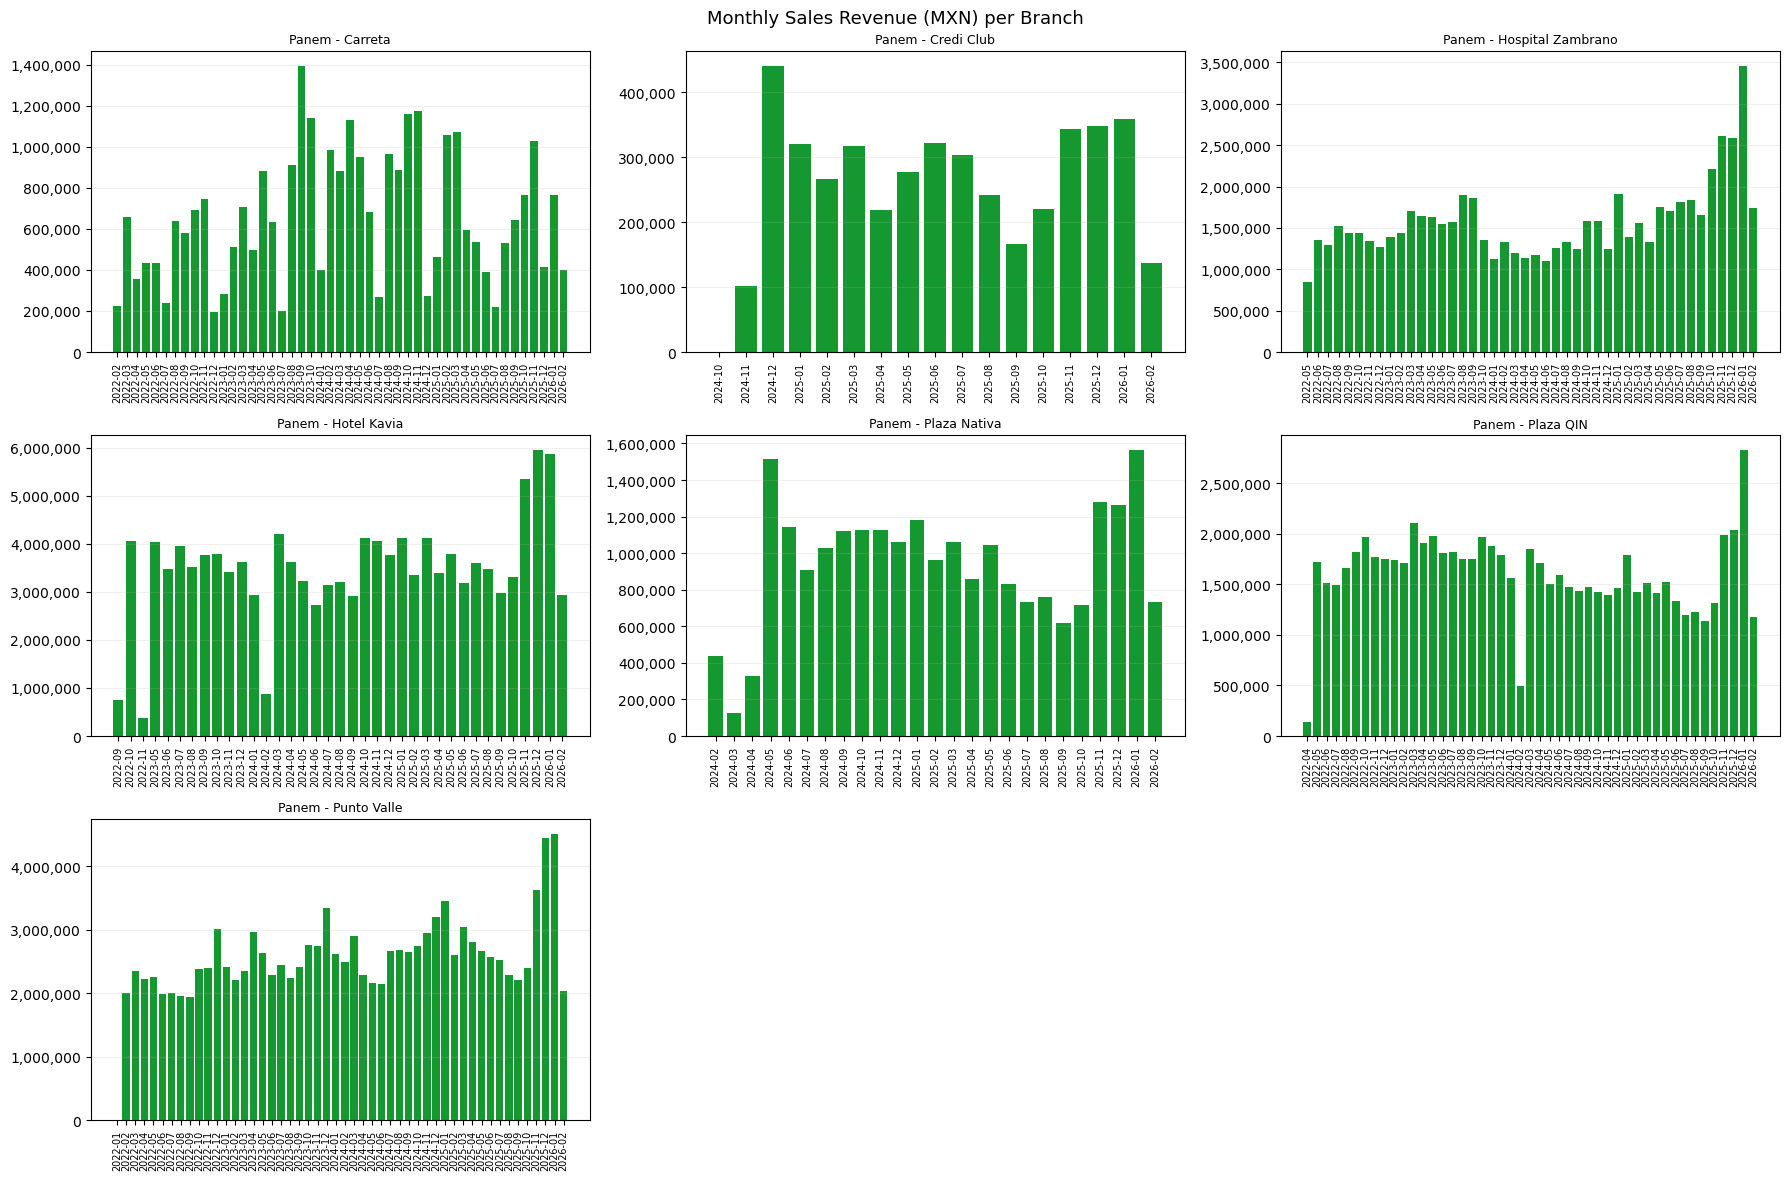

In [9]:
import math

df_monthly = df[(df["is_modifier"] == False) & (df["action"] == "Venta")].copy()
df_monthly["month"] = df_monthly["operating_date"].dt.to_period("M").dt.to_timestamp()

monthly = (
    df_monthly.dropna(subset=["operating_date", "sucursal"])
              .groupby(["sucursal", "month"], as_index=False)["total_ticket"]
              .sum().rename(columns={"total_ticket": "sales"})
)

stores = sorted(monthly["sucursal"].unique())
ncols = 3
nrows = math.ceil(len(stores) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, branch in enumerate(stores):
    g = monthly[monthly["sucursal"] == branch].sort_values("month")
    axes[i].bar(g["month"].dt.strftime("%Y-%m"), g["sales"], color="#169830")
    axes[i].set_title(branch, fontsize=9)
    axes[i].tick_params(axis="x", rotation=90, labelsize=7)
    axes[i].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    axes[i].grid(axis="y", alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Monthly Sales Revenue (MXN) per Branch", fontsize=13)
plt.tight_layout()
plt.show()

## Analysis 7 — Average ticket value by year

The average ticket value tells us how much a customer spends per visit on average.
Tracking this year over year reveals whether the business is moving upmarket
(customers spending more per visit) or if volume growth is coming from more customers.

In [10]:
df_ticket = df[(df["is_modifier"] == False) & (df["action"] == "Venta")].copy()
df_ticket["year"] = df_ticket["operating_date"].dt.year

# Overall average ticket per year
mean_by_year = (
    df_ticket.dropna(subset=["operating_date", "total_ticket"])
             .groupby("year", as_index=False)["total_ticket"]
             .mean().rename(columns={"total_ticket": "avg_ticket_mxn"})
)

print("=== Average ticket value by year (all branches) ===")
print(mean_by_year.to_string(index=False))

# Average ticket per year per branch
mean_by_year_branch = (
    df_ticket.dropna(subset=["operating_date", "total_ticket", "sucursal"])
             .groupby(["sucursal", "year"], as_index=False)["total_ticket"]
             .mean().rename(columns={"total_ticket": "avg_ticket_mxn"})
             .sort_values(["sucursal", "year"])
)
print("\n=== Average ticket value by year per branch ===")
display(mean_by_year_branch)

=== Average ticket value by year (all branches) ===
 year  avg_ticket_mxn
 2022      291.554929
 2023      326.313991
 2024      337.015375
 2025      332.675401
 2026      325.697477

=== Average ticket value by year per branch ===


,sucursal,year,avg_ticket_mxn
0,Panem - Carreta,2022,163.052652
1,Panem - Carreta,2023,220.621859
2,Panem - Carreta,2024,239.568317
3,Panem - Carreta,2025,189.334926
4,Panem - Carreta,2026,193.474909
5,Panem - Credi Club,2024,276.117504
6,Panem - Credi Club,2025,268.062075
7,Panem - Credi Club,2026,224.226050
8,Panem - Hospital Zambrano,2022,252.376301
9,Panem - Hospital Zambrano,2023,255.997679


## Analysis 8 — Cold vs Warm ticket box plot (overall)

Does temperature affect how much customers spend per visit?

We build a daily summary (one row per day) and compare:
- Number of daily transactions on cold days vs warm days
- We use a **bootstrap confidence interval** to test whether the difference is statistically real
  or just random variation

**Bootstrap** = resample each group thousands of times and measure the distribution of differences.
If the 95% confidence interval doesn't include zero, the difference is statistically significant.

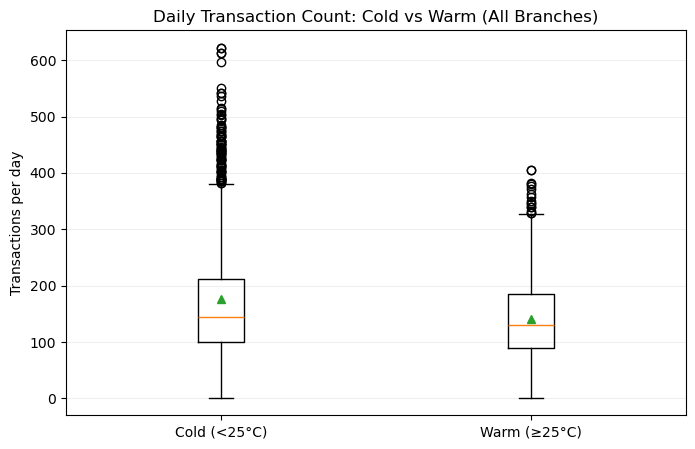

Cold days: 752 | Warm days: 693
Mean diff (warm - cold): -34.9 transactions/day
95% CI: [-46.2, -23.7]
Significant


In [11]:
# Build daily ticket count (one row per day)
daily = (
    df[(df["is_modifier"] == False) & (df["action"] == "Venta")]
    .drop_duplicates("pdv_txn_id")
    .groupby("operating_date", as_index=False)
    .agg(tavg=("tavg", "mean"), ticket_count=("pdv_txn_id", "count"))
)
daily["temp_group"] = np.where(daily["tavg"] >= 25, "warm", "cold")

cold = daily.loc[daily["temp_group"] == "cold", "ticket_count"].values
warm = daily.loc[daily["temp_group"] == "warm", "ticket_count"].values

# Box plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot([cold, warm], tick_labels=["Cold (<25°C)", "Warm (≥25°C)"], showmeans=True)
ax.set_title("Daily Transaction Count: Cold vs Warm (All Branches)")
ax.set_ylabel("Transactions per day")
ax.grid(axis="y", alpha=0.2)
plt.show()

# Bootstrap confidence interval
n = min(len(cold), len(warm))
rng = np.random.default_rng(42)
diffs = np.array([rng.choice(warm, n, replace=True).mean() - rng.choice(cold, n, replace=True).mean() for _ in range(5000)])
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

print(f"Cold days: {len(cold)} | Warm days: {len(warm)}")
print(f"Mean diff (warm - cold): {diffs.mean():,.1f} transactions/day")
print(f"95% CI: [{ci_low:,.1f}, {ci_high:,.1f}]")
print("Significant" if ci_low > 0 or ci_high < 0 else "Not significant at 95% level")

## Summary

Key takeaways:
- Temperature creates distinct product demand patterns — `cold_or_warm` is a valuable feature
- Day of week shows consistent patterns — weekday vs weekend is predictable
- Day part (morning/afternoon/night) reveals very different product mixes — useful for stock timing
- Monthly charts show seasonal trends and any outlier months

**Next step:** `04_eda_hourly_patterns.ipynb` — deep dive into hour-by-hour and holiday patterns.